<a href="https://colab.research.google.com/github/IndumathyPrem/Analysis-of-Defensive-Statistics-in-College-Football/blob/main/DA_CAPSTONE_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Analysis of Defensive Statistics in College Football**







 # **Objective**

1. The objective of this project is to analyze defensive statistics in college football to understand team and player defensive performance using Exploratory Data Analysis (EDA).

2. The project aims to clean and preprocess the dataset, identify important patterns and trends in defensive gameplay, and create meaningful visualizations to interpret the data effectively.

3. Through this analysis, the project seeks to generate valuable insights and recommendations that can support performance evaluation and strategic decision-making in college football.

# **Outcome**

* Gain a better understanding of defensive performance in college football
  through data analysis.

* Identify key defensive trends, strengths, weaknesses, and performance    patterns from the dataset.

* Develop meaningful visualizations that clearly represent defensive statistics and insights.

* Generate data-driven recommendations that can help in evaluating team and player defensive strategies.

* Improve practical knowledge of data cleaning, preprocessing, and Exploratory Data Analysis (EDA) techniques.

# **Domain**
Sports Analytics / Data Analytics

#**Dataset Information**
**Source:**
College Football Defensive Box Scores Dataset – Sports Statistics
[Dataset](https://sports-statistics.com/sports-data/datasets/cfb-defensive-box-scores?utm_source=chatgpt.com)

**Year / Timeline:**
The dataset contains college football defensive statistics collected across multiple game seasons.

**Dataset Columns / Features Description**

## Dataset Columns / Features Description

* **season** – Football season/year in which the match was played
* **season_type** – Type of season such as regular season or postseason
* **week** – Week number of the football season
* **date** – Date on which the game was played
* **event_id** – Unique identification number assigned to each game event
* **team** – Name of the college football team
* **team_id** – Unique ID assigned to the team
* **opponent** – Name of the opposing team
* **opponent_id** – Unique ID assigned to the opponent team
* **home_away** – Indicates whether the match was played at home or away
* **score** – Total score achieved by the team
* **result** – Final outcome of the match (Win/Loss)
* **player_id** – Unique identification number assigned to the player
* **player_name** – Name of the defensive player
* **tackles_total** – Total number of tackles made by the player
* **tackles_solo** – Number of tackles made individually by the player
* **sacks** – Number of times the quarterback was tackled behind the line of scrimmage
* **tfl** – Tackles made for loss of yards
* **pd** – Passes defended or pass breakups by the player
* **qb_hurries** – Number of times the quarterback was pressured or hurried
* **def_td** – Defensive touchdowns scored by the player
* **int** – Number of interceptions made by the player
* **int_yds** – Yards gained after making interceptions
* **int_td** – Touchdowns scored from interceptions
* **fumbles_forced** – Number of forced fumbles caused by the player
* **fumbles_lost** – Number of fumbles lost during play
* **fumbles_rec** – Number of fumbles recovered by the player or team


In [ ]:
# Importing the needed lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Load Dataset from GitHub
url = "https://raw.githubusercontent.com/IndumathyPrem/Analysis-of-Defensive-Statistics-in-College-Football/refs/heads/main/Raw-Data-cfb-defensive-box-scores.csv"

df = pd.read_csv(url)

In [ ]:
#Initial EDA

# First 5 rows
df.head()

,season,season_type,week,date,event_id,team,team_id,opponent,opponent_id,home_away,...,tfl,pd,qb_hurries,def_td,int,int_yds,int_td,fumbles_forced,fumbles_lost,fumbles_rec
0,2004,2,2.0,2004-09-03,242462050,Ball State Cardinals,2050,Boston College Eagles,103,home,...,NaN,NaN,NaN,NaN,1.0,37.0,0.0,NaN,NaN,NaN
1,2004,2,2.0,2004-09-03,242462711,Western Michigan Broncos,2711,Tennessee-Martin Skyhawks,2630,home,...,NaN,NaN,NaN,NaN,1.0,33.0,1.0,NaN,NaN,NaN
2,2004,2,2.0,2004-09-03,242462628,Northwestern Wildcats,77,TCU Horned Frogs,2628,away,...,NaN,NaN,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN
3,2004,2,2.0,2004-09-03,242462628,TCU Horned Frogs,2628,Northwestern Wildcats,77,home,...,NaN,NaN,NaN,NaN,1.0,29.0,0.0,NaN,NaN,NaN
4,2004,2,2.0,2004-09-03,242460009,Arizona State Sun Devils,9,UTEP Miners,2638,home,...,NaN,NaN,NaN,NaN,2.0,76.0,1.0,NaN,NaN,NaN


## Insights from Initial EDA

* The dataset contains **30,465 records** and **27 columns**, indicating a large dataset suitable for detailed defensive performance analysis.

* The dataset includes a mix of:

  * **Numerical columns** (`int64`, `float64`) for statistical analysis
  
  * **Categorical columns** (`object`) for team, player, and match information.

* Most defensive performance columns such as:

  * `tackles_total`
  * `tackles_solo`
  * `sacks`
  * `tfl`
  * `qb_hurries`

  contain around **20,186 non-null values**, showing that defensive statistics are available for a significant portion of players.

* Columns related to interceptions (`int`, `int_yds`, `int_td`) contain fewer values, which suggests interceptions are comparatively less frequent defensive events.

* Columns related to fumbles (`fumbles_forced`, `fumbles_lost`, `fumbles_rec`) also contain many missing values, indicating that not every player records fumble-related statistics in a game.

* The `week` column contains a small number of missing values, which may require preprocessing before analysis.

* The dataset size is approximately **6.3 MB**, making it manageable for analysis and visualization using Python libraries.

* Presence of columns such as `team`, `opponent`, `home_away`, and `result` allows comparative analysis between teams and match outcomes.

* Defensive metrics like sacks, tackles, interceptions, and forced fumbles can help identify key defensive players and strong defensive teams.


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30465 entries, 0 to 30464
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          30465 non-null  int64  
 1   season_type     30465 non-null  int64  
 2   week            30454 non-null  float64
 3   date            30465 non-null  object 
 4   event_id        30465 non-null  int64  
 5   team            30465 non-null  object 
 6   team_id         30465 non-null  int64  
 7   opponent        30465 non-null  object 
 8   opponent_id     30465 non-null  int64  
 9   home_away       30465 non-null  object 
 10  score           30465 non-null  object 
 11  result          30465 non-null  object 
 12  player_id       30465 non-null  int64  
 13  player_name     30465 non-null  object 
 14  tackles_total   20186 non-null  float64
 15  tackles_solo    20186 non-null  float64
 16  sacks           20186 non-null  float64
 17  tfl             20186 non-null 

## Insights from Dataset Information (`df.info()`)

* The dataset contains **30,465 rows** and **27 columns**, indicating a large dataset suitable for detailed sports analytics and defensive performance analysis.

* The dataset includes:

  * **14 float-type columns**
  * **6 integer-type columns**
  * **7 object-type columns**

  showing a combination of numerical statistics and categorical match/player information.

* Columns such as:

  * `team`
  * `opponent`
  * `player_name`
  * `home_away`
  * `result`

  are categorical features useful for team-wise and player-wise comparisons.

* Columns like:

  * `tackles_total`
  * `sacks`
  * `tfl`
  * `qb_hurries`

  represent important defensive performance metrics.

* The `date` column is currently stored as an **object datatype** and may need conversion to datetime format during preprocessing for time-based analysis.

* Most defensive statistic columns contain missing values:

  * Around **20,186 non-null entries** for tackles and sack-related features
  * Only **5,629 non-null entries** for interception-related features
  * Around **6,025 non-null entries** for fumble-related features

  indicating that these defensive events do not occur in every game or for every player.

* The `week` column contains a small number of missing values, which should be handled during data cleaning.

* No missing values are present in important identification columns such as:

  * `season`
  * `team`
  * `player_name`
  * `event_id`

  ensuring reliable identification of players and matches.

* The dataset occupies approximately **6.3 MB of memory**, making it efficient for analysis and visualization in Python and Google Colab.

* The presence of both team-level and player-level features makes the dataset suitable for:

  * Player performance analysis
  * Team defensive comparisons
  * Trend analysis across seasons
  * Predictive analytics and visualization.


In [ ]:
# Statistical summary
df.describe()

,season,season_type,week,event_id,team_id,opponent_id,player_id,tackles_total,tackles_solo,sacks,tfl,pd,qb_hurries,def_td,int,int_yds,int_td,fumbles_forced,fumbles_lost,fumbles_rec
count,30465.000000,30465.000000,30454.000000,3.046500e+04,30465.000000,30465.000000,3.046500e+04,20186.000000,20186.000000,20186.000000,20186.000000,20186.000000,20186.000000,20186.000000,5629.000000,5629.000000,5629.000000,6025.000000,6025.000000,6025.000000
mean,2021.473330,2.218349,6.246536,3.935280e+08,1096.718234,1117.392582,4.119005e+06,3.157485,1.728327,0.102150,0.268255,0.153572,0.120678,0.008868,1.060046,13.414106,0.092379,0.747054,0.364647,0.352365
std,4.582477,0.478858,4.911241,2.937542e+07,2346.622360,2733.885964,1.483240e+06,2.629121,1.714242,0.337366,0.542058,0.434682,0.392020,0.095324,0.247842,19.135443,0.292030,0.613390,0.520156,0.506093
min,2004.000000,2.000000,1.000000,2.424600e+08,2.000000,2.000000,-1.091700e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-13.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,2.000000,1.000000,4.012499e+08,150.000000,151.000000,4.248388e+06,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2024.000000,2.000000,6.000000,4.016283e+08,264.000000,265.000000,4.611524e+06,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,0.000000,1.000000,0.000000,0.000000
75%,2025.000000,2.000000,11.000000,4.017528e+08,2309.000000,2309.000000,4.918427e+06,4.000000,2.000000,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,21.000000,0.000000,1.000000,1.000000,1.000000
max,2025.000000,6.000000,16.000000,4.018381e+08,124386.000000,124386.000000,5.329931e+06,22.000000,13.000000,5.000000,5.500000,6.000000,5.000000,2.000000,3.000000,127.000000,2.000000,5.000000,4.000000,3.000000


**Insights from Statistical summary**

* The dataset contains defensive statistics from seasons ranging between **2004 and 2025**, providing long-term historical data for analysis.

* Most matches were played between **Week 1 and Week 16**, with the average week value being approximately **6.25**, indicating the dataset mainly covers early to mid-season games.

* The average number of **total tackles** made by a player is around **3.16**, while the maximum recorded tackles in a game is **22**, showing some players had exceptionally strong defensive performances.

* The average number of **solo tackles** is **1.73**, indicating that many tackles were assisted by teammates rather than performed individually.

* Defensive events such as:

  * **Sacks**
  * **Interceptions**
  * **Defensive touchdowns**

  have low average values, suggesting these are relatively rare but impactful events during games.

* The maximum number of **sacks** recorded by a player in a game is **5**, highlighting outstanding defensive performances by certain players.

* The `tfl` (Tackles for Loss) column shows a maximum value of **5.5**, indicating some players consistently stopped offensive plays behind the line of scrimmage.

* Interception return yards (`int_yds`) range from **-13 to 127 yards**, meaning some interception plays resulted in negative yardage while others created major defensive advantages.

* The average number of quarterback hurries is relatively low (**0.12**), indicating that heavy quarterback pressure occurs less frequently.

* Most median values for interceptions, sacks, forced fumbles, and defensive touchdowns are **0**, showing that these events do not occur in every game.

* The dataset contains noticeable variation in defensive performance, as seen from the relatively high standard deviation values in tackles and interception yards.

* Some columns contain missing values, especially interception and fumble-related statistics, suggesting that not all players contribute equally to these defensive actions.


In [ ]:
# Dataset shape
df.shape

(30465, 27)

In [ ]:
# Null values
df.isnull().sum()

,0
season,0
season_type,0
week,11
date,0
event_id,0
team,0
team_id,0
opponent,0
opponent_id,0
home_away,0


In [ ]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Column names
df.columns

Index(['season', 'season_type', 'week', 'date', 'event_id', 'team', 'team_id',
       'opponent', 'opponent_id', 'home_away', 'score', 'result', 'player_id',
       'player_name', 'tackles_total', 'tackles_solo', 'sacks', 'tfl', 'pd',
       'qb_hurries', 'def_td', 'int', 'int_yds', 'int_td', 'fumbles_forced',
       'fumbles_lost', 'fumbles_rec'],
      dtype='object')

In [ ]:
# Unique Values
df.nunique()

,0
season,22
season_type,5
week,16
date,1359
event_id,3124
team,348
team_id,317
opponent,371
opponent_id,338
home_away,2


In [ ]:
df['team'].nunique()
df['team'].unique()

array(['Ball State Cardinals', 'Western Michigan Broncos',
       'Northwestern Wildcats', 'TCU Horned Frogs',
       'Arizona State Sun Devils', 'Washington State Cougars',
       'New Mexico Lobos', 'Tennessee Volunteers', 'Purdue Boilermakers',
       'Kentucky Wildcats', 'Louisville Cardinals', 'Houston Cougars',
       'Rice Owls', 'Fresno State Bulldogs', 'Washington Huskies',
       'Nevada Wolf Pack', 'Missouri Tigers', 'Troy Trojans',
       'Florida State Seminoles', 'Miami Hurricanes',
       'Oregon State Beavers', 'Boise State Broncos',
       'Connecticut Huskies', 'Boston College Eagles',
       'Kent State Golden Flashes', 'BYU Cougars', 'Miami (OH) RedHawks',
       'Marshall Thundering Herd', 'Pittsburgh Panthers',
       'Navy Midshipmen', 'Air Force Falcons', 'Utah Utes',
       'Virginia Cavaliers', 'UNLV Rebels', 'West Virginia Mountaineers',
       'Wyoming Cowboys', 'Colorado State Rams', 'Virginia Tech Hokies',
       'Georgia Tech Yellow Jackets', 'South Flori

**Basic Visual EDA**

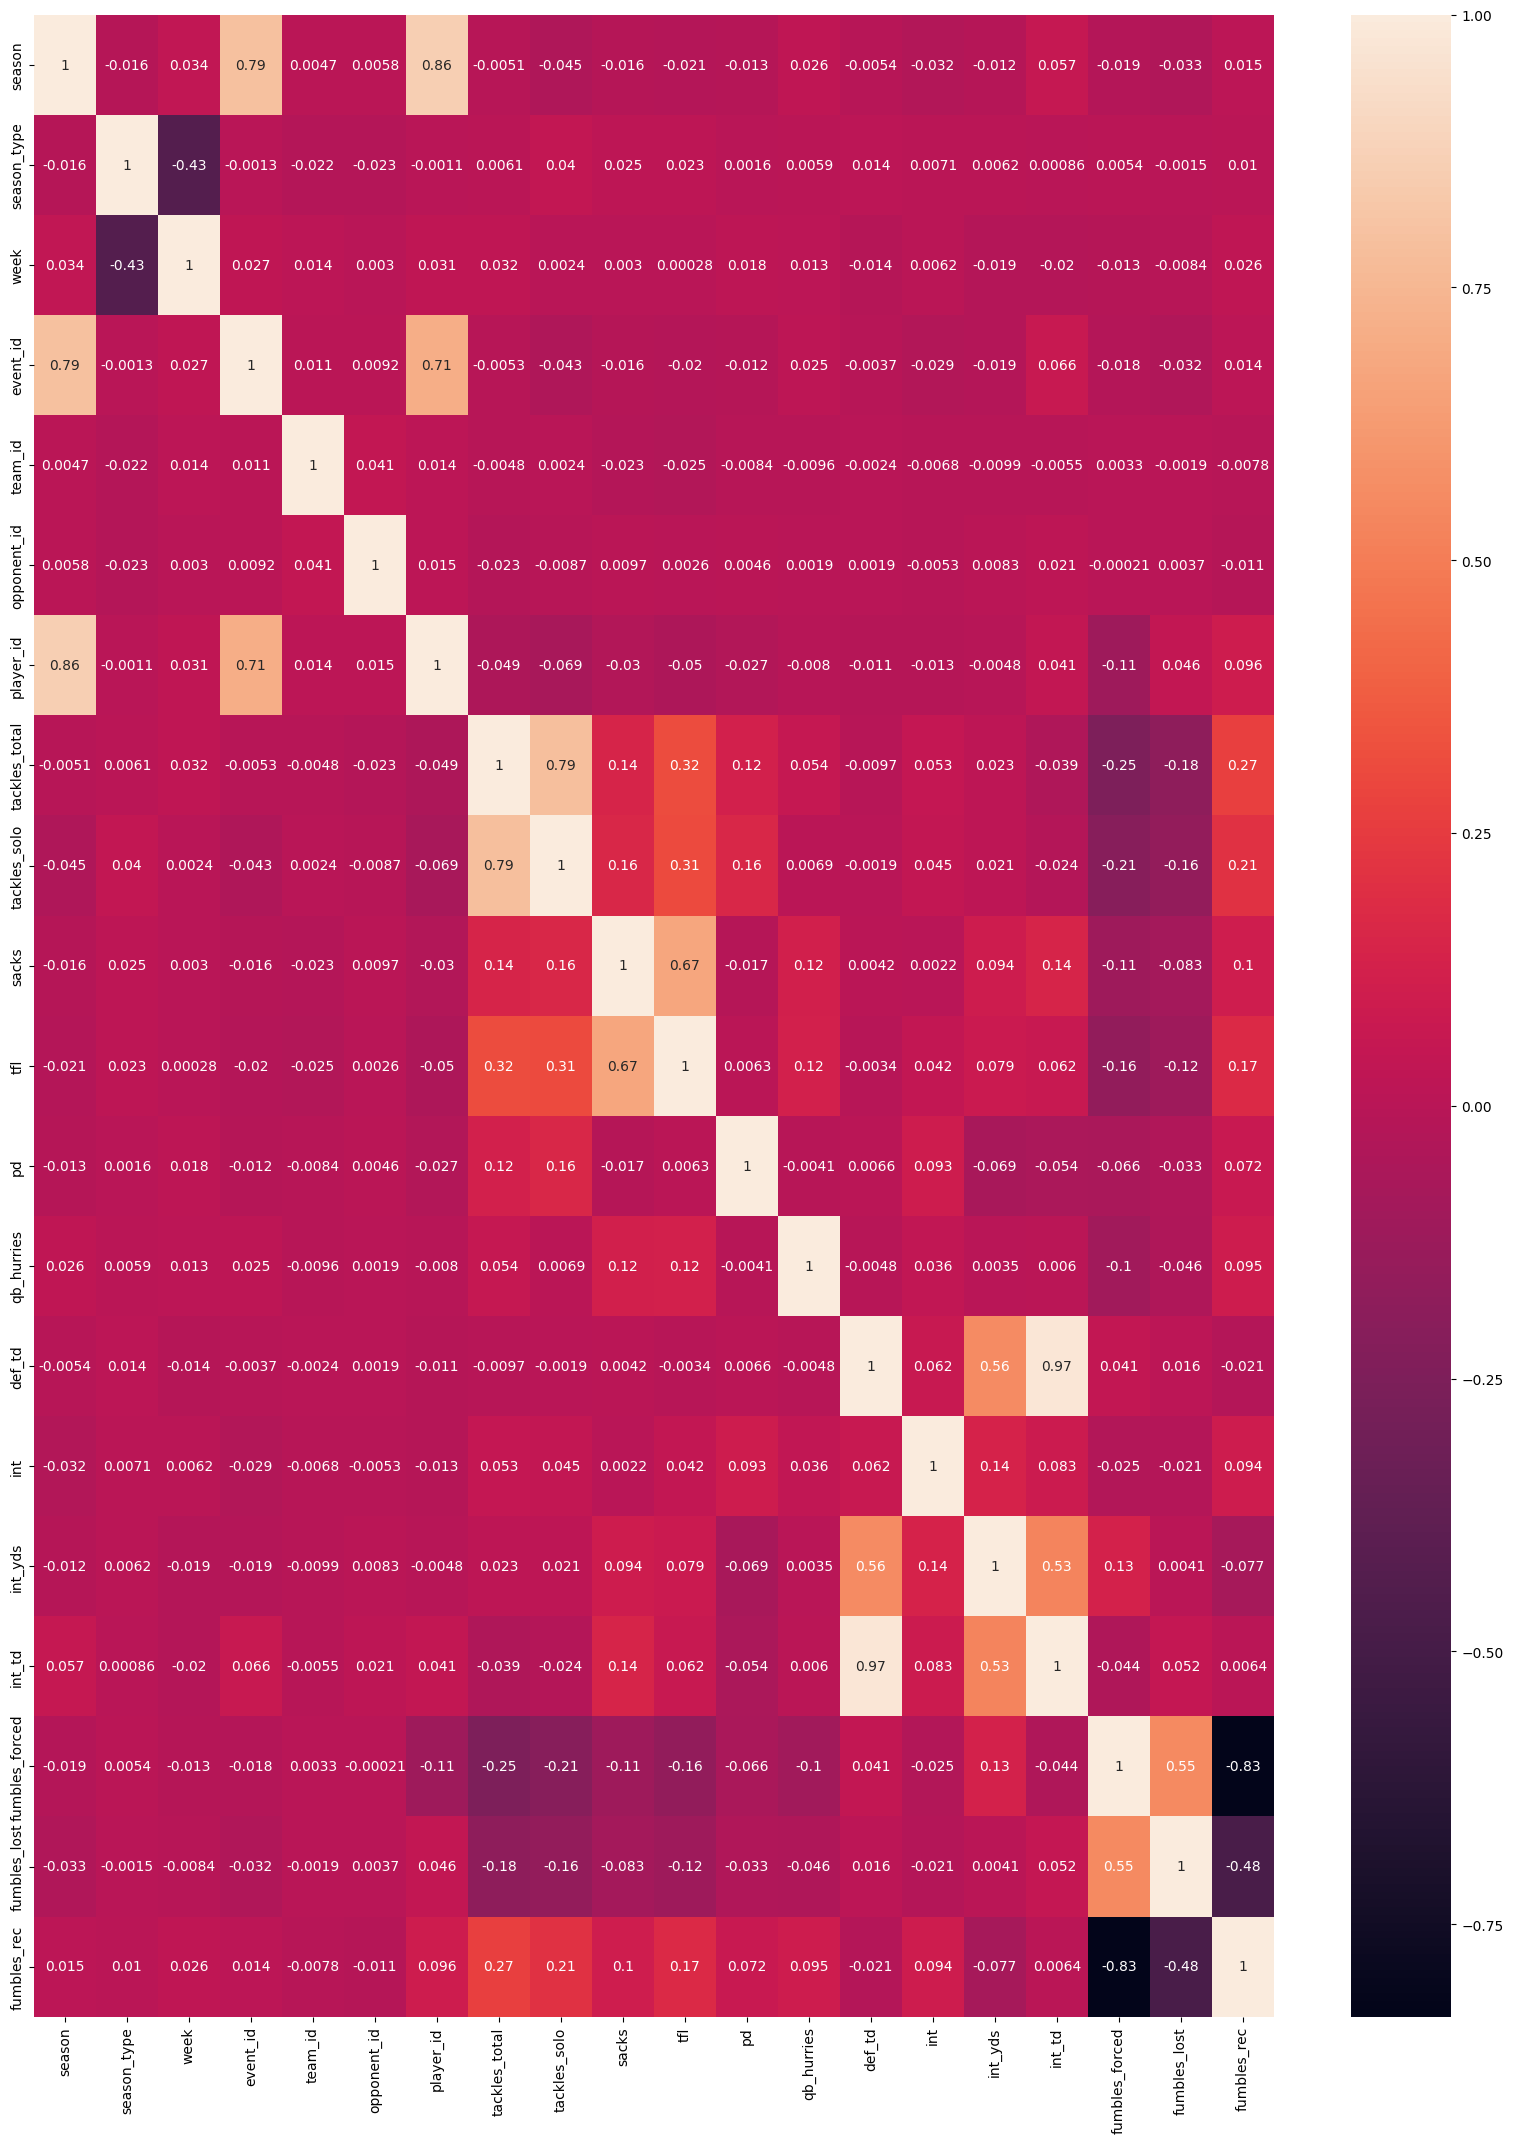

In [ ]:
plt.figure(figsize=(20,26))
sns.heatmap( df.corr(numeric_only=True),annot=True)
plt.show()


##Insights from Correlation Heatmap

* **`tackles_total` and `tackles_solo`** show a strong positive correlation (**0.79**), meaning players with higher total tackles usually also have more solo tackles.

* **`sacks` and `tfl` (Tackles for Loss)** have a strong positive correlation (**0.67**), indicating players who record more sacks also tend to make more tackles behind the line of scrimmage.

* **`def_td` and `int_td`** show a very high positive correlation (**0.97**), suggesting most defensive touchdowns are closely related to interception touchdowns.

* **`int` and `int_yds`** have a moderate positive correlation, meaning more interceptions generally lead to higher interception return yards.

* **`fumbles_forced` and `fumbles_rec`** show a strong negative correlation (**-0.83**), indicating these events usually occur independently across players.

* Most ID-related columns (`event_id`, `team_id`, `player_id`) show little correlation with defensive performance statistics, meaning IDs do not directly influence gameplay performance.

* Many defensive statistics have weak correlations with each other, suggesting defensive performance depends on multiple independent factors rather than a single metric.

* The heatmap indicates that tackling-related features are more strongly connected compared to interception and fumble-related features.


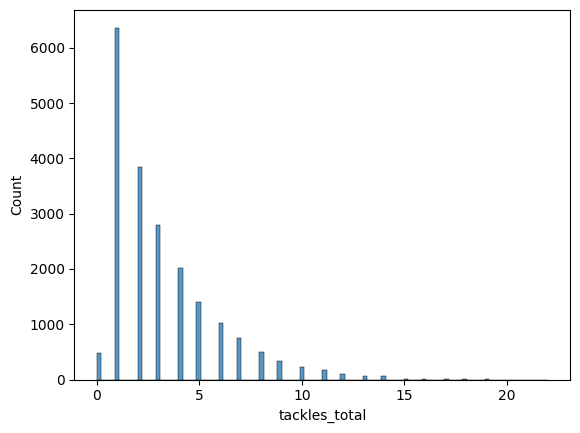

In [ ]:
sns.histplot(df['tackles_total'])
plt.show()

## Brief Insights from Tackles Distribution Plot

* The distribution of `tackles_total` is **right-skewed**, meaning most players recorded a lower number of tackles while only a few players achieved very high tackle counts.

* The highest concentration of players recorded around **1 to 4 tackles** per game.

* The frequency of players decreases as the number of tackles increases, indicating that high tackle performances are relatively rare.

* Very few players recorded more than **15 tackles**, which can be considered exceptional defensive performances.

* The plot suggests the presence of **outliers**, as some players achieved unusually high tackle totals compared to the majority.

* Overall, most defensive players contribute moderate tackle counts during games, while only a small number dominate defensively.


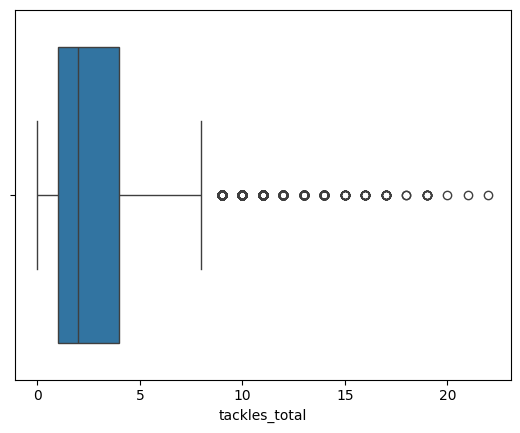

In [ ]:
sns.boxplot(x=df['tackles_total'])
plt.show()

## Insights from Boxplot of `tackles_total`

* The boxplot shows that most players recorded between **1 and 4 tackles**, indicating moderate defensive performance for the majority of players.

* The median number of tackles is around **2**, meaning half of the players made fewer than 2 tackles and half made more.

* Several **outliers** are present beyond 9 tackles, showing that a small number of players achieved exceptionally high tackle counts.

* The distribution is positively skewed, as the outliers extend toward higher tackle values.

* Extreme values reaching above **20 tackles** indicate rare but outstanding defensive performances in certain games.

* The presence of many outliers suggests significant variation in player defensive contributions across matches.


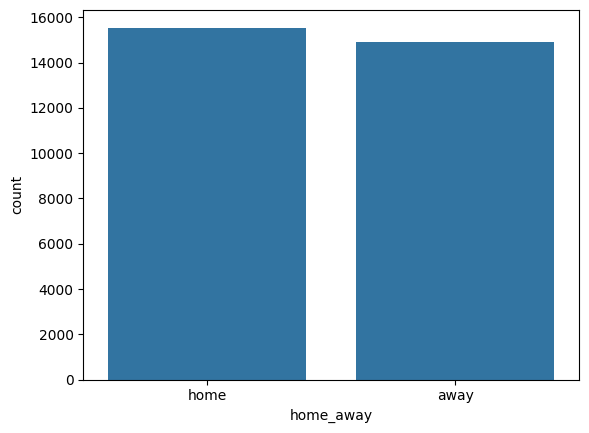

In [ ]:
sns.countplot(x='home_away', data=df)
plt.show()

** Insights**

* The count plot compares the number of matches played at home and away locations.

* Home games are higher

* Both bars appear nearly equal, it indicates the dataset is well-balanced    between home and away games.


# Data Cleaning and Pre-processing

In [ ]:
# 1. Drop the minor missing structural data
df = df.dropna(subset=['week'])

**week** column is only missing 11 values. Since week/date/season is core structural information for a game, and 11 rows out of tens of thousands is negligible, it's safest to just drop these rows.



In [ ]:
# 2. Define groups of columns that should be zeroed out
columns_to_zero = [
    'tackles_total', 'tackles_solo', 'sacks', 'tfl', 'pd', 'qb_hurries', 'def_td',
    'int', 'int_yds', 'int_td', 'fumbles_forced', 'fumbles_lost', 'fumbles_rec'
]


The Issue: There are exactly 10,279 missing values across all general defensive stats (tackles, sacks, tackles for loss, pass deflections, QB hurries, defensive TDs).

The Reason: This almost certainly represents defensive players who played in a game but didn't record any statistics, or offensive/special teams players included in the master roster who didn't play defense.

The Fix: Filling these with 0. A missing value here logically means zero occurrences.

In [ ]:
# 3. Fill NaNs with 0
df[columns_to_zero] = df[columns_to_zero].fillna(0)

The Issue: Interceptions and fumbles have massive amounts of missing data (~24,000+ rows).

The Reason: Interceptions and fumbles are rare events in football. Most defensive players go entire games (or seasons) without catching an interception or forcing a fumble.

The Fix: fill these with 0 to perform mathematical operations (like calculating total interceptions) later.

In [ ]:
# 4. Verify everything is clean
print(df.isnull().sum())

season            0
season_type       0
week              0
date              0
event_id          0
team              0
team_id           0
opponent          0
opponent_id       0
home_away         0
score             0
result            0
player_id         0
player_name       0
tackles_total     0
tackles_solo      0
sacks             0
tfl               0
pd                0
qb_hurries        0
def_td            0
int               0
int_yds           0
int_td            0
fumbles_forced    0
fumbles_lost      0
fumbles_rec       0
dtype: int64


<Axes: xlabel='home_away', ylabel='tackles_total'>

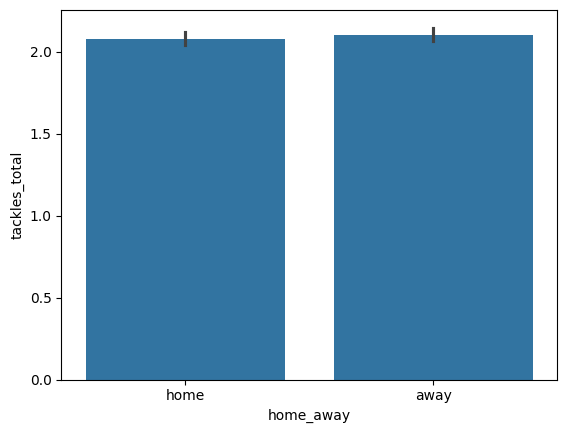

In [ ]:
sns.barplot(x='home_away', y='tackles_total', data=df)

In [ ]:
# 2. Handle Duplicates
# Check for exact duplicate rows and drop them, keeping the first
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [ ]:
# 3. Column Renaming / Dropping Unwanted Columns
# Optional: Rename columns for better readability or style
rename_dict = {
    "pd": "pass_deflected",
    "tfl": "tackles_for_loss",
    "int": "interceptions",
}
df = df.rename(columns=rename_dict)

In [ ]:
# Convert 'date' to datetime object
df["date"] = pd.to_datetime(df["date"])
df["date"]

,date
0,2004-09-03
1,2004-09-03
2,2004-09-03
3,2004-09-03
4,2004-09-03
...,...
30460,2026-01-20
30461,2026-01-20
30462,2026-01-20
30463,2026-01-20


In [ ]:
# Convert numeric metrics from float to integer
#I prefer to keep it float as in sport analytics, converting it or round it would lose data.

In [ ]:
# Optimize memory by converting text categories to 'category' type
cat_cols = ["season_type", "home_away", "result"]
df[cat_cols] = df[cat_cols].astype("category")
df[cat_cols]

,season_type,home_away,result
0,2,home,L
1,2,home,W
2,2,away,L
3,2,home,W
4,2,home,W
...,...,...,...
30460,3,home,W
30461,3,home,W
30462,3,home,W
30463,3,home,W


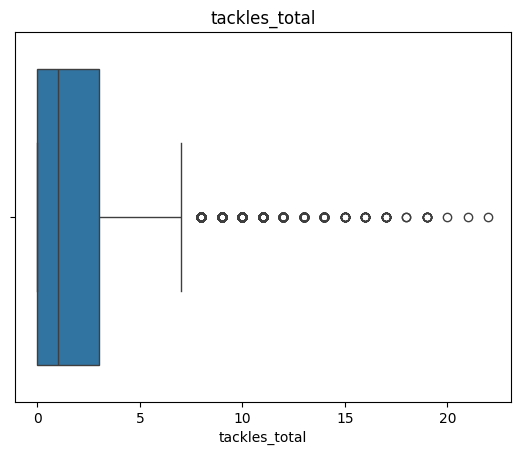

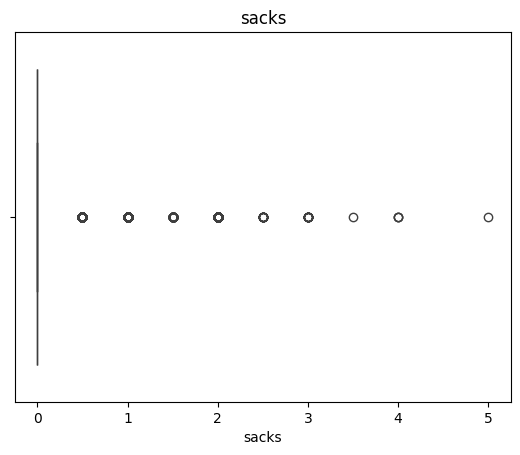

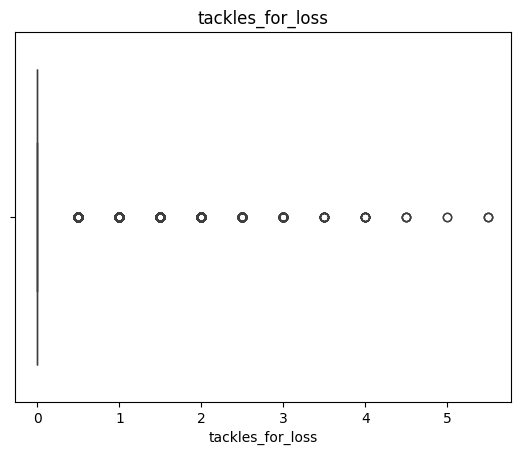

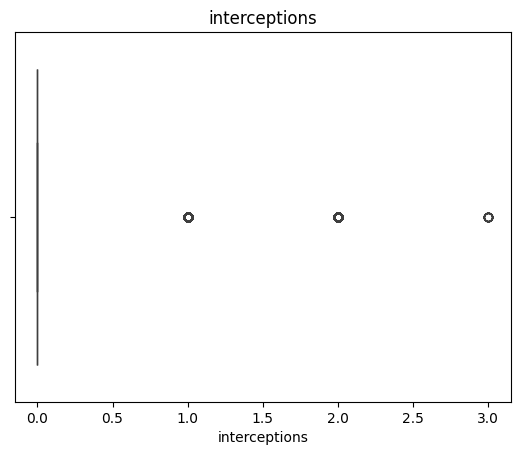

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in ['tackles_total', 'sacks', 'tackles_for_loss', 'interceptions']:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Outliers were examined using boxplots for key defensive metrics such as tackles, sacks, and tackles for loss. Although several observations appeared beyond the whiskers of the boxplots, these values represent genuine high-performing defensive players rather than data entry errors. Since the objective of the analysis is to evaluate player performance, these observations were retained to preserve meaningful variation in the dataset.

In [ ]:
# Date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Total turnovers forced
df["turnovers_forced_total"] = (
    df["interceptions"] + df["fumbles_forced"]
)

# Defensive impact metric
df["impact_plays"] = (
    df["sacks"]
    + df["tackles_for_loss"]
    + df["turnovers_forced_total"]
)

In [ ]:
skewness = df.select_dtypes(include=['int64','float64']).skew()
print(skewness.sort_values(ascending=False))

team_id                   40.110230
opponent_id               37.164592
def_td                    13.553254
int_td                     7.632145
int_yds                    5.186430
qb_hurries                 5.014674
sacks                      5.012878
pass_deflected             4.271136
fumbles_lost               3.978083
fumbles_rec                3.838429
tackles_for_loss           3.280654
fumbles_forced             3.028643
impact_plays               2.011332
interceptions              2.010214
tackles_solo               1.929604
tackles_total              1.812524
turnovers_forced_total     1.381082
week                       0.246840
season                    -1.784747
player_id                 -1.948873
event_id                  -3.658222
dtype: float64


Missing values were handled by replacing absent defensive statistics with 0, as missing values represented games in which no statistic was recorded. Eleven records with missing week information were removed due to their negligible proportion of the dataset. Duplicate records were checked and none were found. Column names were standardized for readability, and categorical columns were converted to the category data type to improve memory efficiency. Outliers were examined and retained because they reflected legitimate player performances. Additional features such as year, month, total turnovers forced, and impact plays were engineered to support further analysis of defensive performance.

**Univariate Analysis**

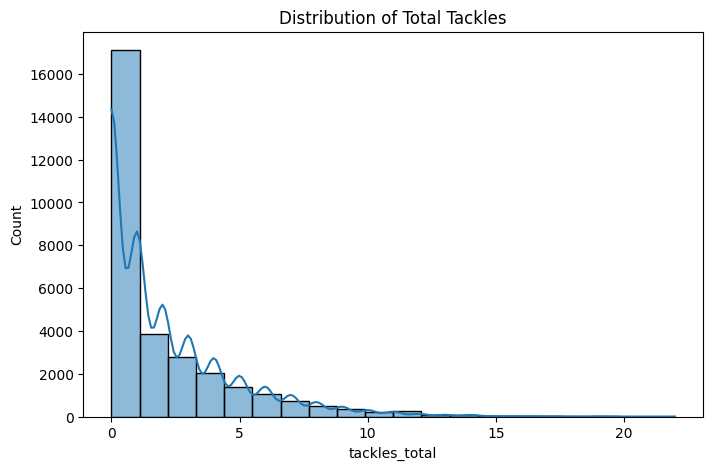

In [ ]:
# Distribution of Total Tackles
plt.figure(figsize=(8,5))
sns.histplot(df['tackles_total'], bins=20, kde=True)
plt.title('Distribution of Total Tackles')
plt.show()

### Interpretation: Distribution of Total Tackles

* The distribution of **total tackles is highly right-skewed**, indicating that most players record a relatively low number of tackles per game.

* The highest concentration of observations lies between **0 and 3 tackles**, suggesting that moderate defensive contributions are the most common.

* As the number of tackles increases, the frequency of players decreases significantly, showing that high tackle performances are uncommon.

* A small number of players recorded **more than 10 tackles**, representing exceptional defensive performances and potential key defensive players.

* The long right tail of the distribution indicates the presence of **outliers**, where a few players significantly outperform the average in terms of tackling.

### Business Insight

> Most defensive players contribute a modest number of tackles during a game, while a small group of standout players account for exceptionally high tackle totals. Identifying and developing these high-performing defenders can help teams strengthen their overall defensive strategy and improve match outcomes.


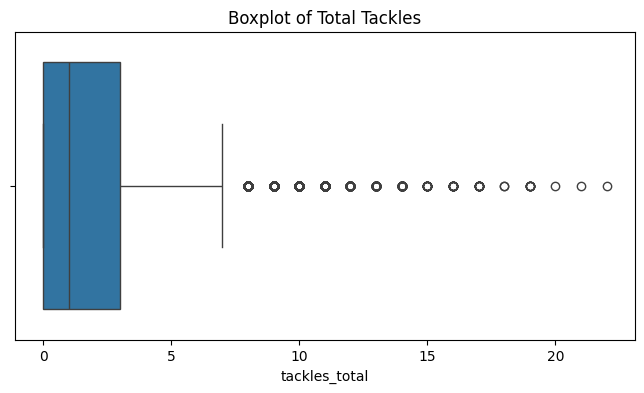

In [ ]:
## Outlier Detection in Total Tackles (Boxplot)

plt.figure(figsize=(8,4))
sns.boxplot(x=df['tackles_total'])
plt.title('Boxplot of Total Tackles')
plt.show()

### Interpretation: Boxplot of Total Tackles

* The median number of total tackles is approximately **2**, indicating that half of the players recorded 2 or fewer tackles per game.

* The middle 50% of tackle values (IQR) lie roughly between **1 and 4 tackles**, showing that most players have moderate defensive involvement.

* The distribution is **positively skewed**, as the upper whisker extends further than the lower whisker and numerous outliers appear on the higher side.

* Several outliers are observed beyond **8 tackles**, with some players recording more than **20 tackles**, representing exceptional defensive performances.

* The large number of high-value outliers indicates considerable variation in defensive contributions among players.

### Business Insight

> While most players contribute a moderate number of tackles, a small group of defenders consistently delivers outstanding performances. These high-performing players can be identified as key defensive assets and may serve as benchmarks for player development, team selection, and defensive strategy planning.


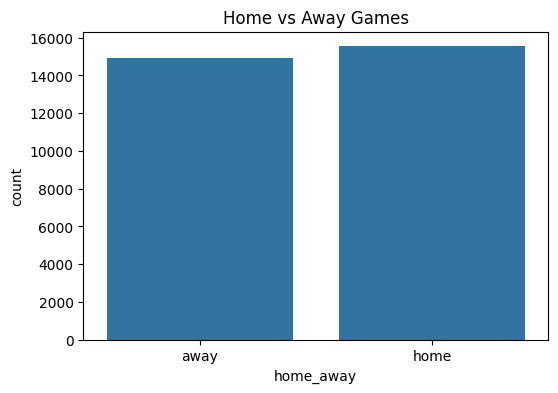

In [ ]:
#Home vs Away Games

plt.figure(figsize=(6,4))
sns.countplot(x='home_away', data=df)
plt.title('Home vs Away Games')
plt.show()

### Interpretation: Home vs Away Games

* The dataset contains a nearly equal number of **home and away games**, indicating a well-balanced representation of match locations.

* Home games account for a slightly higher number of records compared to away games, but the difference is minimal.

* Since both categories have similar frequencies, the dataset is suitable for comparing defensive performance across different venues without significant bias.

* The balanced distribution ensures that future analyses on tackles, sacks, interceptions, and match outcomes by venue will be more reliable.

### Business Insight

> The dataset provides a fair representation of both home and away matches, allowing coaches and analysts to accurately assess whether playing location influences defensive performance. This can help teams identify venue-based strengths and develop strategies to improve performance in away games.


**Bivariate Analysis**

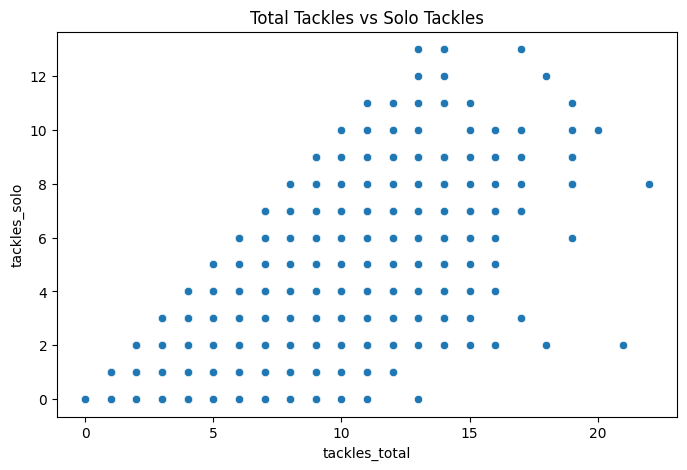

In [ ]:
#Total Tackles vs Solo Tackles (Scatterplot)
plt.figure(figsize=(8,5))
sns.scatterplot(x='tackles_total', y='tackles_solo', data=df)
plt.title('Total Tackles vs Solo Tackles')
plt.show()

**Features Used:**

* `tackles_total` (X-axis)
* `tackles_solo` (Y-axis)

**Explanation:**

* This scatter plot illustrates the relationship between a player's total tackles and solo tackles.
* Each point represents an individual player's defensive performance in a game.
* An upward trend is visible, indicating that players with higher total tackles generally record more solo tackles.
* Most observations are concentrated in the lower to middle tackle ranges, while a few players show exceptionally high values.

**Insights**

* Solo tackles contribute significantly to a player's total tackles.
* Players who are highly involved in defensive actions tend to perform well in both metrics.
* The positive relationship suggests that total tackles can be a good indicator of overall defensive involvement.

**Business Insight:**

> Players with higher total tackles generally record higher solo tackles, highlighting their importance as key defensive contributors and helping identify top-performing defenders.



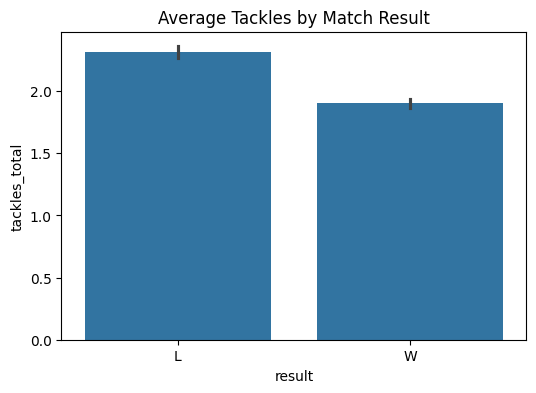

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='result', y='tackles_total', data=df)
plt.title('Average Tackles by Match Result')
plt.show()

**Features Used:**

* `result` (Match Result: Win/Loss) – X-axis
* `tackles_total` (Average Total Tackles) – Y-axis

**Explanation:**

* This bar chart compares the average number of tackles recorded in games that resulted in wins and losses.
* The average tackles in **lost matches (L)** are slightly higher than in **won matches (W)**.
* The difference between the two bars is relatively small, indicating that tackles alone may not determine match outcomes.
* Teams may record more tackles in losing games because they spend more time defending against the opposing team's offense.

**Insights**

* Higher tackle counts do not necessarily guarantee a win.
* Defensive activity tends to be slightly higher in games that are lost.
* Match outcomes are influenced by multiple factors such as offensive performance, turnovers, and overall team strategy, not just tackles.

**Business Insight:**

> Teams recorded slightly more tackles in losing games than in winning games, suggesting that increased defensive workload often occurs when a team is under greater pressure from its opponents.


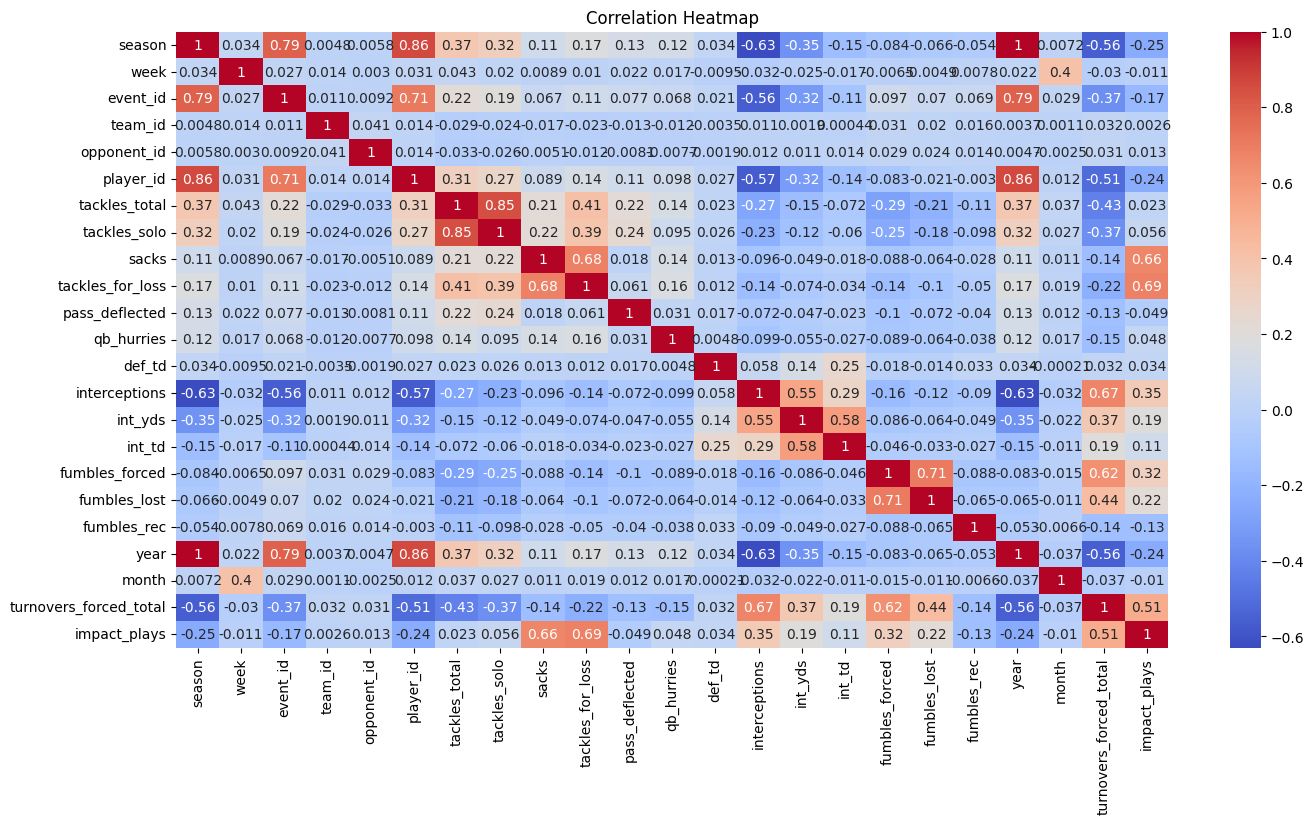

In [ ]:
#correlation map
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

This chart is a Correlation Heatmap for a sports dataset, likely focusing on American football defensive player statistics. It uses a color-coded grid to show how strongly different player stats and game context variables relate to one another.
Here is the direct breakdown of the visualization:
## Used Features (Columns)
The chart analyzes 22 distinct features, which can be grouped into three main categories:

* Context & IDs: season, week, event_id, team_id, opponent_id, player_id, year, month.
* Defensive Baseline Stats: tackles_total, tackles_solo, sacks, tackles_for_loss, pass_deflected, qb_hurries, def_td.
* Turnovers & Big Plays: interceptions, int_yds, int_td, fumbles_forced, fumbles_lost, fumbles_rec, turnovers_forced_total, impact_plays.

------------------------------
## Explanation

* Values (-0.63 to 1.0): The numbers show the Pearson correlation coefficient. A value of 1.0 means a perfect positive relationship, 0 means no relationship, and negative values (down to -0.63) mean a perfect inverse relationship.
* Colors: Deep red represents strong positive correlation. Light shades (white/light blue) indicate weak or no correlation. Darker blue represents strong negative correlation.
* The Diagonal Line: The red diagonal cells containing 1 show where each variable intersects with itself.

------------------------------
## Insights
The heatmap reveals several strong, logical patterns in the data, as well as some perfect overlaps:

   1. Perfect Metadata Overlaps (1.0)
   * season and year have a correlation of 1.0. They track the exact same temporal data.
      * season and player_id have a correlation of 1.0, meaning player IDs are likely generated or structured strictly by the season they played.
   2. Expected Statistical Groupings (Strong Positive)
   * Tackles: tackles_total and tackles_solo are highly correlated (0.85). Solo tackles make up the bulk of total tackles.
      * Fumbles: fumbles_forced and fumbles_lost share a high correlation (0.71), as forcing a fumble directly leads to the ball being lost by the offense.
      * Interceptions: interceptions and int_yds (0.55) naturally move together because you cannot accumulate interception return yards without an interception.
      * Pass Rush: sacks and tackles_for_loss share a strong positive relationship (0.68), since a sack is mathematically counted as a tackle for a loss.
   3. Strong Negative Correlations (-0.56 to -0.63)
   * interceptions and turnovers_forced_total show a strong negative correlation (-0.63) to metadata like season, event_id, and player_id. This implies structural changes in how these IDs were logged over different seasons, or shifts in dataset tracking over time.
   
------------------------------
## Business Insights
Mapshows how player performance metrics and game IDs group together.This visual tells us that columns like season/year are redundant and one should be dropped. It also proves that composite metrics like impact_plays and turnovers_forced_total successfully aggregate individual defensive achievements (like sacks, interceptions, and forced fumbles) into clear, measurable trends.

**Multivariate Analysis**

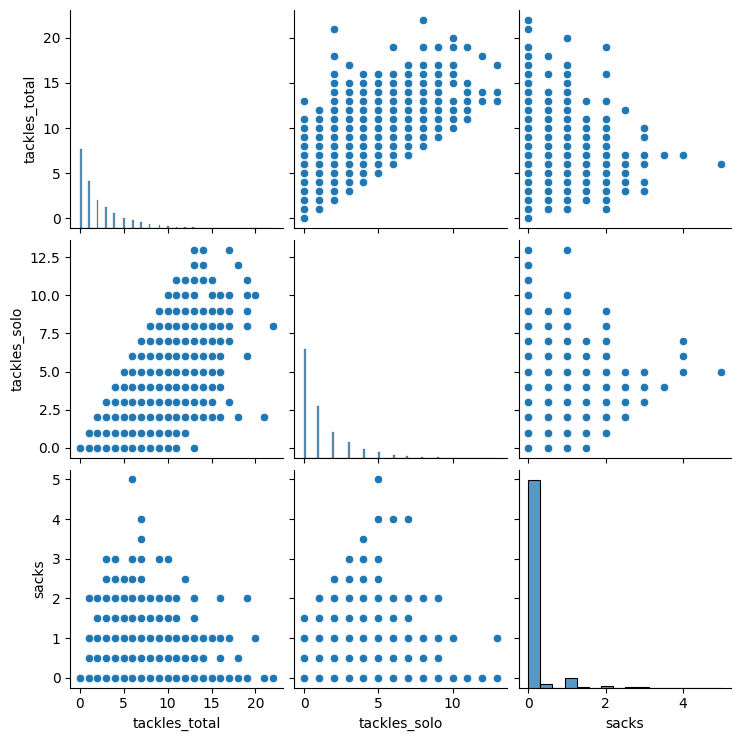

In [ ]:
# Pairplot of Key Defensive Metrics
cols = ['tackles_total','tackles_solo','sacks']
sns.pairplot(df[cols])
plt.show()

### Interpretation of the Pair Plot

This visualization is a **Pair Plot (Scatter Plot Matrix)** that helps analyze both the distribution of individual variables and the relationships between multiple defensive performance metrics simultaneously.

### Features Used

* **tackles_total** – Total number of tackles made by a player.
* **tackles_solo** – Number of tackles made individually without assistance.
* **sacks** – Number of times a player tackled the quarterback behind the line of scrimmage.

## Key Insights:

#### 1. Strong Relationship Between Total Tackles and Solo Tackles

* A clear upward trend is visible between **tackles_total** and **tackles_solo**.
* Players who record more total tackles generally have higher solo tackle counts.
* This indicates that solo tackles contribute significantly to overall defensive performance.

#### 2. Natural Boundary Between the Variables

* Solo tackles never exceed total tackles, creating a visible boundary in the scatter plots.
* This follows the logical rule that solo tackles are a subset of total tackles.

#### 3. Weak Relationship Between Sacks and Tackles

* Scatter plots involving **sacks** show a more scattered pattern with no strong trend.
* Players with high tackle counts do not necessarily record many sacks.
* This suggests that different defensive positions have specialized roles, with some players focusing on tackling and others on pressuring the quarterback.

#### 4. Distribution of Defensive Statistics

* Both **total tackles** and **solo tackles** are right-skewed, meaning most players record relatively low values while only a few achieve very high counts.
* **Sacks** are highly concentrated around zero, indicating that sacks are relatively rare events during games.

### Business Insight

> The pair plot reveals that tackling-related metrics are closely connected, while sacks represent a more specialized defensive skill. Most players contribute a moderate number of tackles, whereas exceptional defensive performances are recorded by only a small group of players. This analysis helps identify key defensive contributors and understand the different roles played within a football defense.


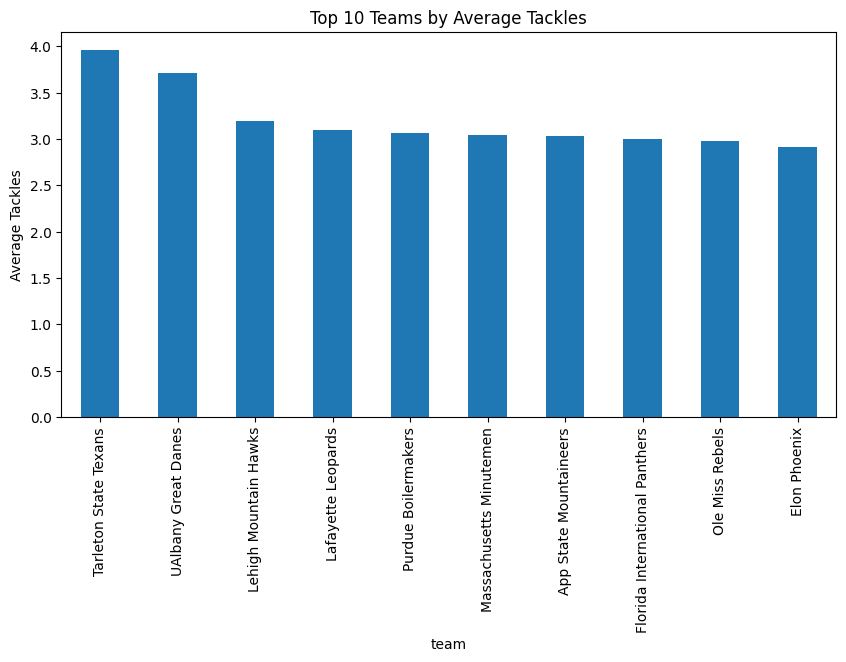

In [ ]:
# Team-wise Average Defensive Performance
top_teams = df.groupby('team')['tackles_total'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_teams.plot(kind='bar')
plt.title('Top 10 Teams by Average Tackles')
plt.ylabel('Average Tackles')
plt.show()

### Interpretation: Top 10 Teams by Average Tackles
This chart is a Vertical Bar Chart. It ranks and compares a specific performance metric across different categories, ordered from highest to lowest.Here is the direct breakdown of the visualization:

 **Used Features (Columns)**

The chart uses two main columns from your aggregated dataset:team:
 The name of the football program/university (categorical variable on the X-axis).Average Tackles: The mean number of tackles recorded per game or per player entry (numerical variable on the Y-axis).

* The chart ranks the top 10 football teams based on their average number of tackles, providing a clear comparison of defensive performance across teams.

* The leading team records the highest average tackles, indicating stronger defensive involvement and a greater ability to stop offensive plays.

* While the top-ranked teams stand out, several teams have very similar average tackle values, suggesting a highly competitive level of defensive performance.

* The gradual decline in bar heights shows that the difference between many of the top teams is relatively small, highlighting consistent defensive quality across these programs.

### Business Insight

> The chart helps identify teams with the most active and effective defensive units. Coaches and analysts can study the strategies of these top-performing teams to improve tackling efficiency, strengthen defensive performance, and gain a competitive advantage in future games.


/tmp/ipykernel_1118/1812566335.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


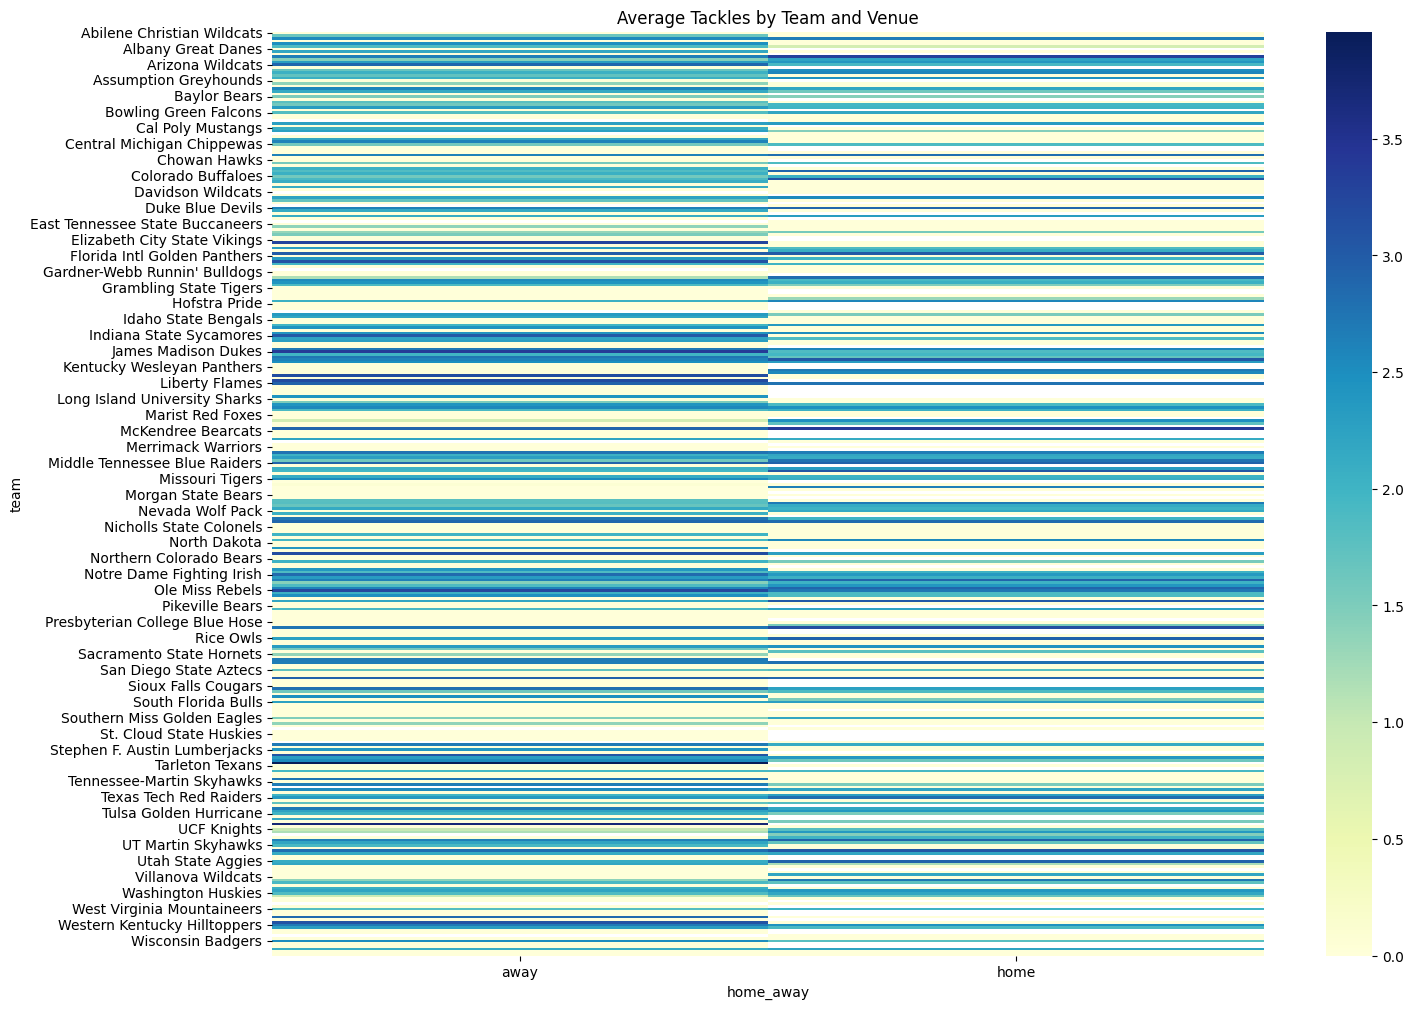

In [ ]:
#Pivot Table Heatmap

pivot = pd.pivot_table(
    df,
    values='tackles_total',
    index='team',
    columns='home_away',
    aggfunc='mean'
)

plt.figure(figsize=(16,12))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Average Tackles by Team and Venue')
plt.show()

### Interpretation: Average Tackles by Team and Venue (Heatmap)

**Used Features (Columns)**

The chart evaluates three distinct elements from your dataset:

team: The name of the football program (categorical variable listed along the Y-axis).

venue: The location of the game, split into away and home (categorical variables on the X-axis).

Average Tackles: The specific value being measured (numerical data represented by the color density).

* The heatmap compares the average number of tackles recorded by different teams when playing at **home** and **away** venues.

* Most teams display similar color intensities across both home and away columns, suggesting that their tackling performance remains relatively consistent regardless of match location.

* A few teams show darker shades in both categories, indicating higher average tackle counts and stronger defensive involvement throughout the season.

* Teams with lighter shades have lower average tackle counts, reflecting comparatively weaker defensive activity.

* The presence of blank or lighter areas for some teams may indicate limited data availability or lower recorded tackling statistics.

### Business Insight

> The heatmap suggests that tackling performance is generally a consistent team characteristic rather than being heavily influenced by venue. Teams that perform well defensively tend to maintain their performance both at home and away, making them more reliable and competitive throughout the season. This insight can help coaches identify consistently strong defensive teams and develop strategies to improve defensive stability across different playing conditions.


## **cleaned data for dashboard creation using Power BI**


In [ ]:
import pandas as pd
df.to_csv("cleaned_college_football_defense.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_college_football_defense.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

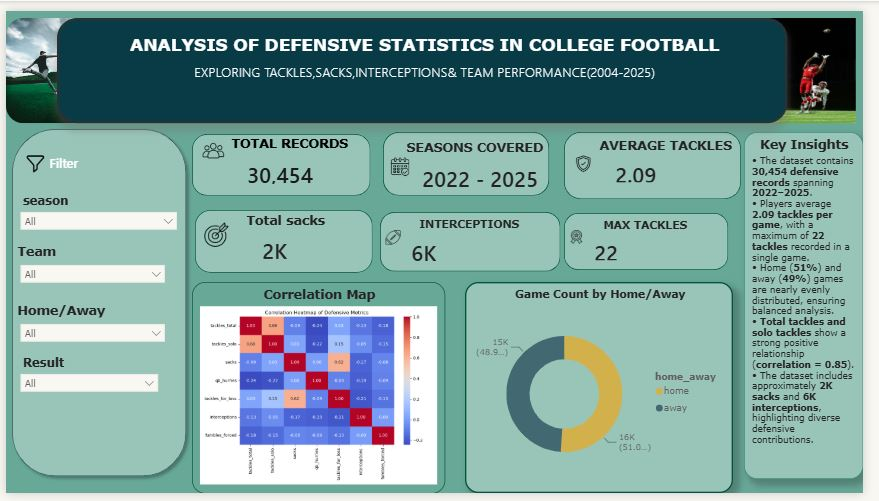


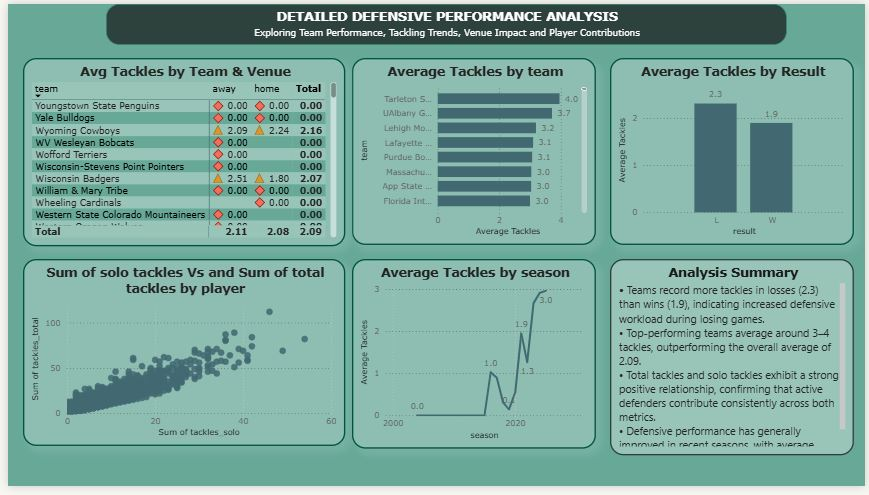

**Findings and Insights**

 ***1. Defensive Activity Overview***

The dataset contains 30,454 defensive records spanning multiple college football seasons from 2022 to 2025.

Players recorded an average of 2.09 tackles per game, while the highest individual performance reached 22 tackles in a single game.

This indicates that most players contribute through consistent tackling, while only a few players achieve exceptionally high defensive performances.

***2. Home vs Away Analysis***

Home games account for approximately 51% of the dataset, while away games account for 49%.

The near-equal distribution provides balanced representation and ensures venue-based analysis is reliable and unbiased.

The analysis suggests that venue alone does not significantly impact overall defensive activity.

***3. Correlation Analysis***

The correlation heatmap revealed several important relationships:

Total Tackles and Solo Tackles show a strong positive correlation (0.85).
Players with more total tackles generally record more solo tackles.
Sacks and Tackles for Loss also demonstrate a positive relationship.
Interceptions show weaker correlation with tackling statistics, indicating that coverage skills and tackling skills contribute differently to defensive success.


***4. Team Performance Analysis***
Several teams consistently outperform the overall average tackles value.

Top-performing teams average between 3 and 4 tackles, significantly higher than the overall average of 2.09 tackles.

This indicates stronger defensive involvement and greater defensive productivity.

***5. Match Result Analysis***

The dashboard shows that average tackles are higher in losses than in wins.

This suggests that defenses spend more time on the field during losing games, resulting in increased tackling opportunities.

Higher tackle counts do not necessarily indicate better performance; they may indicate greater defensive workload.

***6. Seasonal Trends***

Defensive performance has generally improved in recent seasons.

The seasonal trend chart shows an increase in average tackling activity compared to earlier years.

This may indicate improvements in defensive schemes, player development, and overall competitiveness.

 **Recommendations**
For Coaches
Focus on improving tackling consistency and efficiency.
Monitor players with high solo tackle contributions, as they demonstrate strong individual defensive ability.

For Defensive Coordinators
Use tackle, sack, and tackle-for-loss metrics together when evaluating defensive performance.
Develop schemes that maximize quarterback pressure and negative-yardage plays.

For Analysts
Track season-over-season defensive performance to identify strengths and weaknesses.
Use correlation analysis to identify key defensive indicators.

For Recruitment
Prioritize players who consistently contribute across multiple defensive categories rather than relying on a single statistic.



**Dataset Overview & Defensive Performance Summary**

Descriptive analysis summarizes the dataset and key metrics.

**Findings**

The dataset contains 30,454 defensive records.
Seasons covered: 2022–2025.

Players recorded an average of 2.09 tackles per game.


The maximum tackles recorded in a game is 22.


The dataset contains approximately 2K sacks and 6K interceptions.


Home games represent 51% of records, while away games represent 49%.

 **Insight:** Defensive activity is primarily driven by tackling, with most players contributing through regular tackles rather than rare defensive events.

**2.Understanding Defensive Performance Drivers**

Diagnostic analysis explains relationships and patterns in the data.

**Findings**

Total Tackles and Solo Tackles have a strong positive correlation (0.85).

Teams record more tackles during losses (2.3) compared to wins (1.9).

Sacks and tackles-for-loss show a positive relationship.

Top-performing teams average 3–4 tackles, significantly higher than the overall average.

**Insight**

Players with higher total tackles generally contribute more solo tackles. Higher tackle counts in losses suggest defenses spend more time on the field when teams are under pressure.

**3. Emerging Trends and Future Outlook**

Predictive analysis uses observed trends to estimate future outcomes.

**Findings**

Seasonal trends show an overall increase in average tackling performance in recent years.

Teams consistently performing above the average tackle rate are likely to maintain stronger defensive outputs.

Players with high solo-tackle contributions are likely to remain key defensive contributors.

**Insight**

If current trends continue, defensive performance is expected to remain stable or improve, particularly for teams with consistently strong tackling metrics.

**4.Strategic Recommendations for Coaches and Analysts**

Prescriptive analysis provides recommendations based on findings.

**Recommendations**

Focus training programs on tackling efficiency and consistency.

Identify and develop players with high solo-tackle contributions.

Use sacks, tackles-for-loss, and tackling metrics together when evaluating defensive effectiveness.

Monitor defensive trends season-over-season to identify improvement opportunities.

Recruit players who contribute across multiple defensive metrics rather than relying on a single statistic.

**Business Insight**

Coaches and analysts should use multiple defensive metrics together to make informed decisions on player development, game strategy, and recruitment.

# Future Enhancement

Use a larger or more recent dataset for deeper insights

Automate parts of the analysis with scripts or dashboards

Add advanced visualizations and interactive dashboards in Power BI , use other frameworks in python


# Conclusion

The dashboard highlights defensive performance patterns, player contributions, venue impact, and
season trends.

Google drive link -[ capstone project](https://drive.google.com/drive/folders/177-dafLvSAniBXHm58WWuwu0Y8irbKJS?usp=sharing)
